# CLIP Similarity Visualization
**Demonstrating that CLIP doesn't understand relations: s(I, Q) ≈ s(I, Q⁻)**

This notebook creates a visually appealing figure showing that CLIP assigns similar similarity scores to a correct caption and its foil (negated/swapped) caption.

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import numpy as np
from pathlib import Path

# Optional: Use tueplots for publication-quality figures
try:
    from tueplots import figsizes, fontsizes
    USE_TUEPLOTS = True
except ImportError:
    USE_TUEPLOTS = False
    print("tueplots not installed, using default matplotlib settings")

## 1. Input: Image, Captions, and Similarities

Modify the variables below with your image path, captions, and similarity scores.

In [22]:
# =============================================================================
# INPUT: Modify these values
# =============================================================================

# Path to your image
IMAGE_PATH = "/mnt/lustre/work/oh/owl336/LabCLIP_v2/CLIP-not-BoW-unimodally/blue_cat_red_dog.png"  # Change this to your image path

# Correct caption (Q)
CAPTION = "a blue cat and a red dog"

# Foil/negative caption (Q⁻) - e.g., relation swap, attribute change, etc.
FOIL_CAPTION = "a red cat and a blue dog"

# Similarity scores (you can compute these or input manually)
SIM_CAPTION = 0.346      # s(I, Q)  - similarity with correct caption
SIM_FOIL = 0.352         # s(I, Q⁻) - similarity with foil caption

# Optional: Type of manipulation for the title
MANIPULATION_TYPE = ""  # e.g., "Relation Swap", "Attribute Change", "Subject Swap"

# Output filename
OUTPUT_FILENAME = "clip_similarity_demo"

## 2. Create the Visualization

In [23]:
import textwrap
def create_clip_similarity_figure(
    image_path,
    caption,
    foil_caption,
    sim_caption,
    sim_foil,
    output_path=None,
    figsize=(8, 4.5),
):
    """
    Create a visually appealing figure showing CLIP similarity scores.
    
    Layout:
    - Left: Image
    - Right: Two caption boxes with similarity scores
    """
    
    # Colors - using a professional palette
    COLOR_CORRECT = "#228833"    # Green for correct caption
    COLOR_FOIL = "#BB5566"       # Red/pink for foil caption
    COLOR_BG_CORRECT = "#E8F5E9" # Light green background
    COLOR_BG_FOIL = "#FFEBEE"    # Light red background
    
    # Create figure
    fig = plt.figure(figsize=figsize, dpi=150)
    fig.patch.set_facecolor('white')
    
    # Create grid: image on left (35%), text on right (65%)
    gs = fig.add_gridspec(1, 2, width_ratios=[0.35, 0.65], wspace=0.08)
    
    # === LEFT: Image ===
    ax_img = fig.add_subplot(gs[0, 0])
    ax_img.set_aspect('equal')
    
    # Load and display image
    if Path(image_path).exists():
        img = Image.open(image_path)
        ax_img.imshow(img)
    else:
        # Placeholder if image doesn't exist
        ax_img.text(0.5, 0.5, "[Image]\n" + str(image_path), 
                    ha='center', va='center', fontsize=10,
                    transform=ax_img.transAxes,
                    bbox=dict(boxstyle='round', facecolor='#f0f0f0', edgecolor='#cccccc'))
    
    ax_img.axis('off')
    ax_img.set_title("Image $I$", fontsize=12, fontweight='bold', pad=12)
    
    # === RIGHT: Captions and Similarities ===
    ax_text = fig.add_subplot(gs[0, 1])
    ax_text.set_xlim(0, 1)
    ax_text.set_ylim(0, 1)
    ax_text.axis('off')
    
    # --- Caption Q Box ---
    box1_y = 0.70
    box_height = 0.32
    caption_box = mpatches.FancyBboxPatch(
        (0.02, box1_y - box_height/2), 0.96, box_height,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        facecolor=COLOR_BG_CORRECT,
        edgecolor=COLOR_CORRECT,
        linewidth=2.5,
        transform=ax_text.transAxes,
        zorder=1
    )
    ax_text.add_patch(caption_box)
    
    # Label: Caption Q
    ax_text.text(0.05, box1_y + 0.10, "Caption $Q$:", 
                 fontsize=11, fontweight='bold', color=COLOR_CORRECT,
                 transform=ax_text.transAxes, va='center')
    
    # Caption text (wrapped)
    wrapped_caption = textwrap.fill(f'"{caption}"', width=50)
    ax_text.text(0.05, box1_y - 0.02, wrapped_caption, 
                 fontsize=11, style='italic', color='#333333',
                 transform=ax_text.transAxes, va='center',
                 linespacing=1.3)
    
    # Similarity score for caption Q
    ax_text.text(0.95, box1_y - 0.10, f"$s(I, Q) = {sim_caption:.3f}$", 
                 fontsize=12, fontweight='bold', color=COLOR_CORRECT,
                 transform=ax_text.transAxes, va='center', ha='right',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                          edgecolor=COLOR_CORRECT, linewidth=1.5))
    
    # --- Foil Q^- Box ---
    box2_y = 0.30
    foil_box = mpatches.FancyBboxPatch(
        (0.02, box2_y - box_height/2), 0.96, box_height,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        facecolor=COLOR_BG_FOIL,
        edgecolor=COLOR_FOIL,
        linewidth=2.5,
        transform=ax_text.transAxes,
        zorder=1
    )
    ax_text.add_patch(foil_box)
    
    # Label: Foil Q^-
    ax_text.text(0.05, box2_y + 0.10, "Foil $Q^-$:", 
                 fontsize=11, fontweight='bold', color=COLOR_FOIL,
                 transform=ax_text.transAxes, va='center')
    
    # Foil text (wrapped)
    wrapped_foil = textwrap.fill(f'"{foil_caption}"', width=50)
    ax_text.text(0.05, box2_y - 0.02, wrapped_foil, 
                 fontsize=11, style='italic', color='#333333',
                 transform=ax_text.transAxes, va='center',
                 linespacing=1.3)
    
    # Similarity score for foil Q^-
    ax_text.text(0.95, box2_y - 0.10, f"$s(I, Q^-) = {sim_foil:.3f}$", 
                 fontsize=12, fontweight='bold', color=COLOR_FOIL,
                 transform=ax_text.transAxes, va='center', ha='right',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                          edgecolor=COLOR_FOIL, linewidth=1.5))
    
    # --- Approximation indicator between boxes ---
    mid_y = (box1_y + box2_y) / 2
    ax_text.text(0.5, mid_y, "≈", fontsize=20, fontweight='bold', 
                 color='#888888', transform=ax_text.transAxes, 
                 va='center', ha='center')
    
    plt.tight_layout()
    
    # Save if output path provided
    if output_path:
        plt.savefig(f"{output_path}.pdf", bbox_inches='tight', dpi=300)
        plt.savefig(f"{output_path}.png", bbox_inches='tight', dpi=300)
        print(f"Saved to {output_path}.pdf and {output_path}.png")
    
    plt.show()
    
    return fig

/tmp/ipykernel_3684490/780583310.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to clip_similarity_demo.pdf and clip_similarity_demo.png


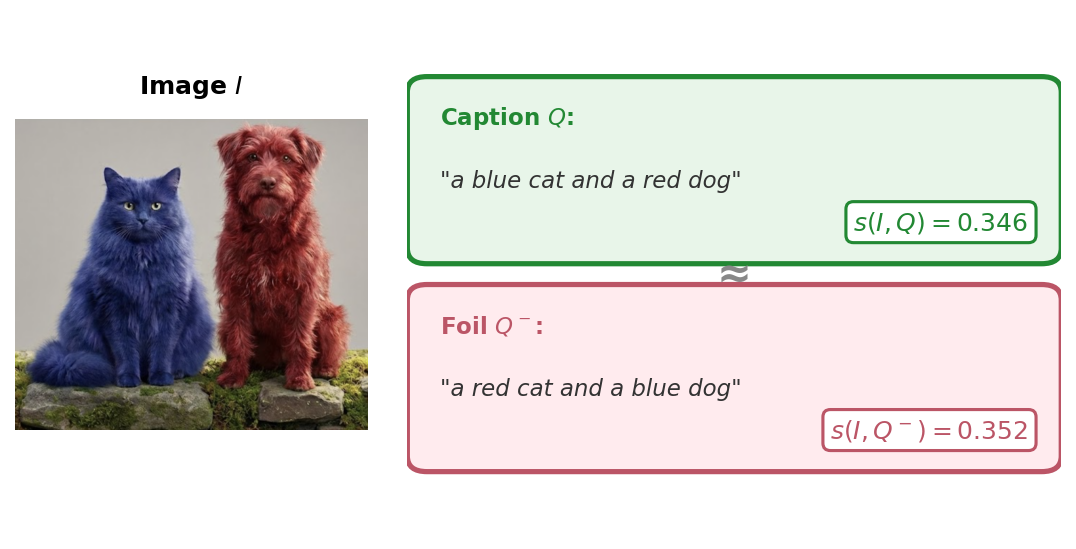

In [24]:
# Create the visualization
fig = create_clip_similarity_figure(
    image_path=IMAGE_PATH,
    caption=CAPTION,
    foil_caption=FOIL_CAPTION,
    sim_caption=SIM_CAPTION,
    sim_foil=SIM_FOIL,
    output_path=OUTPUT_FILENAME,
    figsize=(9, 4.5),
)

## 3. Alternative Layout: Vertical Stack

In [ ]:
def create_clip_similarity_vertical(
    image_path,
    caption,
    foil_caption,
    sim_caption,
    sim_foil,
    manipulation_type="Relation Swap",
    output_path=None,
    figsize=(4, 5),
):
    """
    Create a vertical layout: Image on top, captions below with bar comparison.
    """
    
    # Colors
    COLOR_CORRECT = "#228833"
    COLOR_FOIL = "#BB5566"
    
    fig, axes = plt.subplots(3, 1, figsize=figsize, dpi=150,
                              gridspec_kw={'height_ratios': [2.5, 1, 1.2]})
    fig.patch.set_facecolor('white')
    
    # === TOP: Image ===
    ax_img = axes[0]
    if Path(image_path).exists():
        img = Image.open(image_path)
        ax_img.imshow(img)
    else:
        ax_img.text(0.5, 0.5, f"[Image]\n{image_path}", 
                    ha='center', va='center', fontsize=10,
                    transform=ax_img.transAxes,
                    bbox=dict(boxstyle='round', facecolor='#f0f0f0'))
    ax_img.axis('off')
    
    # === MIDDLE: Captions ===
    ax_cap = axes[1]
    ax_cap.set_xlim(0, 1)
    ax_cap.set_ylim(0, 1)
    ax_cap.axis('off')
    
    # Correct caption
    ax_cap.text(0.5, 0.75, f'Q: "{caption}"', 
                fontsize=9, ha='center', va='center', color=COLOR_CORRECT,
                fontweight='bold', transform=ax_cap.transAxes)
    
    # Foil caption
    ax_cap.text(0.5, 0.25, f'Q⁻: "{foil_caption}"', 
                fontsize=9, ha='center', va='center', color=COLOR_FOIL,
                fontweight='bold', transform=ax_cap.transAxes)
    
    # === BOTTOM: Bar comparison ===
    ax_bar = axes[2]
    
    # Normalize for visual comparison (show relative difference)
    max_sim = max(sim_caption, sim_foil) * 1.1
    min_sim = min(sim_caption, sim_foil) * 0.9
    
    bars = ax_bar.barh([1, 0], [sim_caption, sim_foil], 
                        color=[COLOR_CORRECT, COLOR_FOIL],
                        edgecolor='white', linewidth=1.5, height=0.6)
    
    # Add value labels
    ax_bar.text(sim_caption + 0.005, 1, f'{sim_caption:.3f}', 
                va='center', ha='left', fontsize=10, fontweight='bold')
    ax_bar.text(sim_foil + 0.005, 0, f'{sim_foil:.3f}', 
                va='center', ha='left', fontsize=10, fontweight='bold')
    
    ax_bar.set_yticks([1, 0])
    ax_bar.set_yticklabels(['s(I, Q)', 's(I, Q⁻)'], fontsize=10)
    ax_bar.set_xlim(min_sim, max_sim + 0.05)
    ax_bar.set_xlabel('CLIP Similarity', fontsize=10)
    
    # Clean styling
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.spines['left'].set_color('#aaaaaa')
    ax_bar.spines['bottom'].set_color('#aaaaaa')
    
    # Add difference annotation
    diff = sim_caption - sim_foil
    ax_bar.text(0.5, -0.35, f'Δ = {diff:+.4f}  (nearly identical!)', 
                transform=ax_bar.transAxes, ha='center', fontsize=10,
                fontweight='bold', color='#CC3311')
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(f"{output_path}_vertical.pdf", bbox_inches='tight', dpi=300)
        plt.savefig(f"{output_path}_vertical.png", bbox_inches='tight', dpi=300)
        print(f"Saved to {output_path}_vertical.pdf and {output_path}_vertical.png")
    
    plt.show()
    return fig

In [ ]:
# Create vertical layout version
fig_vert = create_clip_similarity_vertical(
    image_path=IMAGE_PATH,
    caption=CAPTION,
    foil_caption=FOIL_CAPTION,
    sim_caption=SIM_CAPTION,
    sim_foil=SIM_FOIL,
    manipulation_type=MANIPULATION_TYPE,
    output_path=OUTPUT_FILENAME,
    figsize=(4, 5.5),
)

## 4. Minimal Version (Just the Key Message)

In [ ]:
def create_clip_similarity_minimal(
    image_path,
    caption,
    foil_caption,
    sim_caption,
    sim_foil,
    output_path=None,
    figsize=(5, 2.5),
):
    """
    Minimal, clean version focusing on the key equation:
    s(I, Q) ≈ s(I, Q⁻)
    """
    
    COLOR_CORRECT = "#228833"
    COLOR_FOIL = "#BB5566"
    
    fig, (ax_img, ax_eq) = plt.subplots(1, 2, figsize=figsize, dpi=150,
                                         gridspec_kw={'width_ratios': [1, 1.5]})
    fig.patch.set_facecolor('white')
    
    # Image
    if Path(image_path).exists():
        img = Image.open(image_path)
        ax_img.imshow(img)
    else:
        ax_img.add_patch(mpatches.Rectangle((0.1, 0.1), 0.8, 0.8, 
                         facecolor='#f5f5f5', edgecolor='#cccccc',
                         transform=ax_img.transAxes))
        ax_img.text(0.5, 0.5, "Image", ha='center', va='center',
                    fontsize=12, transform=ax_img.transAxes)
    ax_img.axis('off')
    
    # Equation display
    ax_eq.set_xlim(0, 1)
    ax_eq.set_ylim(0, 1)
    ax_eq.axis('off')
    
    # Main equation
    ax_eq.text(0.5, 0.7, 
               f"$s(I, Q) = {sim_caption:.3f}$",
               fontsize=14, ha='center', va='center', color=COLOR_CORRECT,
               fontweight='bold', transform=ax_eq.transAxes)
    
    ax_eq.text(0.5, 0.5, "≈", fontsize=20, ha='center', va='center',
               color='#666666', transform=ax_eq.transAxes)
    
    ax_eq.text(0.5, 0.3, 
               f"$s(I, Q^-) = {sim_foil:.3f}$",
               fontsize=14, ha='center', va='center', color=COLOR_FOIL,
               fontweight='bold', transform=ax_eq.transAxes)
    
    # Captions below
    ax_eq.text(0.5, 0.1, 
               f'Q: "{caption}"\nQ⁻: "{foil_caption}"',
               fontsize=8, ha='center', va='top', color='#555555',
               style='italic', transform=ax_eq.transAxes)
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(f"{output_path}_minimal.pdf", bbox_inches='tight', dpi=300)
        plt.savefig(f"{output_path}_minimal.png", bbox_inches='tight', dpi=300)
        print(f"Saved to {output_path}_minimal.pdf and {output_path}_minimal.png")
    
    plt.show()
    return fig

In [ ]:
# Create minimal version
fig_min = create_clip_similarity_minimal(
    image_path=IMAGE_PATH,
    caption=CAPTION,
    foil_caption=FOIL_CAPTION,
    sim_caption=SIM_CAPTION,
    sim_foil=SIM_FOIL,
    output_path=OUTPUT_FILENAME,
)